# Comparativa de modelos - Regresión

Objetivo: comparar dos versiones de cada modelo de regresión usando validación cruzada y un conjunto holdout sobre Housing Prices.

## 1) Librerías

In [ ]:
!pip install pandas matplotlib seaborn scikit-learn


In [12]:
# Importamos sklearn y las herramientas necesarias para repetir el mismo flujo que en clasificación.
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import get_scorer

from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression, Ridge, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor


## 2) Cargar datos

In [2]:
data = pd.read_csv("student_performance.csv")
data.head()


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


In [3]:
data.dtypes

school          str
sex             str
age           int64
address         str
famsize         str
Pstatus         str
Medu          int64
Fedu          int64
Mjob            str
Fjob            str
reason          str
guardian        str
traveltime    int64
studytime     int64
failures      int64
schoolsup       str
famsup          str
paid            str
activities      str
nursery         str
higher          str
internet        str
romantic        str
famrel        int64
freetime      int64
goout         int64
Dalc          int64
Walc          int64
health        int64
absences      int64
G1            int64
G2            int64
G3            int64
dtype: object

In [4]:
data.info()


<class 'pandas.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      649 non-null    str  
 1   sex         649 non-null    str  
 2   age         649 non-null    int64
 3   address     649 non-null    str  
 4   famsize     649 non-null    str  
 5   Pstatus     649 non-null    str  
 6   Medu        649 non-null    int64
 7   Fedu        649 non-null    int64
 8   Mjob        649 non-null    str  
 9   Fjob        649 non-null    str  
 10  reason      649 non-null    str  
 11  guardian    649 non-null    str  
 12  traveltime  649 non-null    int64
 13  studytime   649 non-null    int64
 14  failures    649 non-null    int64
 15  schoolsup   649 non-null    str  
 16  famsup      649 non-null    str  
 17  paid        649 non-null    str  
 18  activities  649 non-null    str  
 19  nursery     649 non-null    str  
 20  higher      649 non-null    str  
 21  inte

## 3) Preparar datos

In [5]:
variables_a_descartar = []
variables_categoricas = ["school", "sex", "famsize", "Mjob", "Fjob", "famsup"]
variables_numericas = [
    "age"
]
variable_dependiente = "G1"

X = data.drop([variable_dependiente] + variables_a_descartar, axis=1)
y = data[variable_dependiente].astype(float)

print(X.head())
print(y.head())


  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher  ...   
1     GP   F   17       U     GT3       T     1     1  at_home     other  ...   
2     GP   F   15       U     LE3       T     1     1  at_home     other  ...   
3     GP   F   15       U     GT3       T     4     2   health  services  ...   
4     GP   F   16       U     GT3       T     3     3    other     other  ...   

  romantic famrel  freetime  goout  Dalc Walc health absences  G2  G3  
0       no      4         3      4     1    1      3        4  11  11  
1       no      5         3      3     1    1      3        2  11  11  
2       no      4         3      2     2    3      3        6  13  12  
3      yes      3         2      2     1    1      5        0  14  14  
4       no      4         3      2     1    2      5        0  13  13  

[5 rows x 32 columns]
0     0.0
1     9.0
2    12.0
3    14.0
4    11.0
Name: G1

## 4) Definir holdout y métricas

In [27]:
random_state = 42
X_train, X_holdout, y_train, y_holdout = train_test_split(
    X, y, test_size=0.2, random_state=random_state
)

# En sklearn varios errores se reportan con signo negativo para que "más alto" siga significando "mejor".
metricas_disponibles = ["r2", "neg_mean_absolute_error", "neg_root_mean_squared_error", "neg_mean_absolute_percentage_error"]
metricas_seleccionadas = ["r2", "neg_mean_absolute_percentage_error"]

for metrica in metricas_seleccionadas:
    if metrica not in metricas_disponibles:
        raise ValueError(f"La métrica {metrica} no está en la lista disponible")

scoring = {metrica: metrica for metrica in metricas_seleccionadas}
cv = KFold(n_splits=5, shuffle=True, random_state=random_state)


## 5) Grilla de comparación

In [28]:
preprocesamiento = ColumnTransformer([
    (
        "numerico",
        Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]),
        variables_numericas,
    ),
    (
        "categorico",
        Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore"))
        ]),
        variables_categoricas,
    ),
])

comparison_grid = [
    {"modelo": "KNN", "version": "k=5", "pipeline": Pipeline([("preprocesamiento", preprocesamiento), ("modelo", KNeighborsRegressor(n_neighbors=5))])},
    {"modelo": "KNN", "version": "k=11", "pipeline": Pipeline([("preprocesamiento", preprocesamiento), ("modelo", KNeighborsRegressor(n_neighbors=11))])},
    {"modelo": "KNN", "version": "k=11, weights='distance'", "pipeline": Pipeline([("preprocesamiento", preprocesamiento), ("modelo", KNeighborsRegressor(n_neighbors=11, weights='distance'))])},
    {"modelo": "Regresión lineal", "version": "OLS", "pipeline": Pipeline([("preprocesamiento", preprocesamiento), ("modelo", LinearRegression())])},
    {"modelo": "Regresión lineal", "version": "Ridge(alpha=1)", "pipeline": Pipeline([("preprocesamiento", preprocesamiento), ("modelo", Ridge(alpha=1.0, random_state=random_state))])},
    {"modelo": "Regresión lineal", "version": "ElasticNet(alpha=1, l1_ratio=0.5)", "pipeline": Pipeline([("preprocesamiento", preprocesamiento), ("modelo", ElasticNet(alpha=1.0, l1_ratio=0.5, random_state=random_state))])},
    {"modelo": "Árbol de decisión", "version": "max_depth=4", "pipeline": Pipeline([("preprocesamiento", preprocesamiento), ("modelo", DecisionTreeRegressor(max_depth=4, random_state=random_state))])},
    {"modelo": "Árbol de decisión", "version": "max_depth=8", "pipeline": Pipeline([("preprocesamiento", preprocesamiento), ("modelo", DecisionTreeRegressor(max_depth=8, random_state=random_state))])},
    {"modelo": "Random forest", "version": "200 árboles", "pipeline": Pipeline([("preprocesamiento", preprocesamiento), ("modelo", RandomForestRegressor(n_estimators=200, random_state=random_state))])},
    {"modelo": "Random forest", "version": "400 árboles", "pipeline": Pipeline([("preprocesamiento", preprocesamiento), ("modelo", RandomForestRegressor(n_estimators=400, random_state=random_state))])},
    {"modelo": "SVM", "version": "C=0.5", "pipeline": Pipeline([("preprocesamiento", preprocesamiento), ("modelo", SVR(C=0.5, kernel="rbf", epsilon=0.1))])},
    {"modelo": "SVM", "version": "C=2", "pipeline": Pipeline([("preprocesamiento", preprocesamiento), ("modelo", SVR(C=2.0, kernel="rbf", epsilon=0.1))])},
    {"modelo": "SVM", "version": "C=1", "pipeline": Pipeline([("preprocesamiento", preprocesamiento), ("modelo", SVR(C=1.0, kernel="rbf", epsilon=0.1))])},
    {"modelo": "SVM", "version": "C=10", "pipeline": Pipeline([("preprocesamiento", preprocesamiento), ("modelo", SVR(C=10.0, kernel="rbf", epsilon=0.1))])},
    {"modelo": "Red neuronal", "version": "(32,)", "pipeline": Pipeline([("preprocesamiento", preprocesamiento), ("modelo", MLPRegressor(hidden_layer_sizes=(32,), max_iter=1000, random_state=random_state))])},
    {"modelo": "Red neuronal", "version": "(64, 32)", "pipeline": Pipeline([("preprocesamiento", preprocesamiento), ("modelo", MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=1000, random_state=random_state))])},
]

pd.DataFrame([{"modelo": item["modelo"], "version": item["version"]} for item in comparison_grid])


,modelo,version
0,KNN,k=5
1,KNN,k=11
2,KNN,"k=11, weights='distance'"
3,Regresión lineal,OLS
4,Regresión lineal,Ridge(alpha=1)
5,Regresión lineal,"ElasticNet(alpha=1, l1_ratio=0.5)"
6,Árbol de decisión,max_depth=4
7,Árbol de decisión,max_depth=8
8,Random forest,200 árboles
9,Random forest,400 árboles


## 6) CV out-of-set + holdout

In [29]:
resultados = []

for item in comparison_grid:
    pipeline = item["pipeline"]

    cv_scores = cross_validate(
        estimator=pipeline,
        X=X_train,
        y=y_train,
        cv=cv,
        scoring=scoring,
        return_train_score=False,
        n_jobs=None,
    )

    pipeline.fit(X_train, y_train)

    fila = {
        "modelo": item["modelo"],
        "version": item["version"],
    }

    for metrica in metricas_seleccionadas:
        cv_mean = cv_scores[f"test_{metrica}"].mean()
        cv_std = cv_scores[f"test_{metrica}"].std()
        holdout_score = get_scorer(metrica)(pipeline, X_holdout, y_holdout)

        if metrica.startswith("neg_"):
            cv_mean = -cv_mean
            cv_std = -cv_std
            holdout_score = -holdout_score
        fila[f"cv_mean_{metrica}"] = cv_mean
        fila[f"cv_std_{metrica}"] = cv_std
        fila[f"holdout_{metrica}"] = holdout_score
        fila[f"gap_{metrica}"] = holdout_score - cv_mean

    resultados.append(fila)

resultados_df = pd.DataFrame(resultados)
resultados_df


/Users/goviedb/Development/UNAB/Teaching/R/my-r-project/Ejemplos/.venv_nb/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/goviedb/Development/UNAB/Teaching/R/my-r-project/Ejemplos/.venv_nb/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/goviedb/Development/UNAB/Teaching/R/my-r-project/Ejemplos/.venv_nb/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/goviedb/Development/UNAB/Teaching/R/my-r-project/Ejemplos/.venv_nb/lib/python3.14/site-packages/sklearn/neural_net

,modelo,version,cv_mean_r2,cv_std_r2,holdout_r2,gap_r2,cv_mean_neg_mean_absolute_percentage_error,cv_std_neg_mean_absolute_percentage_error,holdout_neg_mean_absolute_percentage_error,gap_neg_mean_absolute_percentage_error
0,KNN,k=5,0.031785,0.050237,0.047706,0.015921,1.049382e+14,-2.098765e+14,0.193551,-1.049382e+14
1,KNN,k=11,0.070872,0.057823,-0.023112,-0.093985,1.041433e+14,-2.082865e+14,0.201501,-1.041433e+14
2,KNN,"k=11, weights='distance'",-0.117561,0.145360,-0.056103,0.061458,1.039659e+14,-2.079319e+14,0.204752,-1.039659e+14
3,Regresión lineal,OLS,0.120414,0.045217,0.035571,-0.084842,1.018922e+14,-2.037845e+14,0.190239,-1.018922e+14
4,Regresión lineal,Ridge(alpha=1),0.121880,0.044138,0.034898,-0.086982,1.016096e+14,-2.032192e+14,0.190283,-1.016096e+14
5,Regresión lineal,"ElasticNet(alpha=1, l1_ratio=0.5)",0.003970,0.003011,-0.065313,-0.069283,9.821311e+13,-1.964262e+14,0.210051,-9.821311e+13
6,Árbol de decisión,max_depth=4,-0.003807,0.082035,-0.023406,-0.019599,1.034808e+14,-2.069615e+14,0.198045,-1.034808e+14
7,Árbol de decisión,max_depth=8,-0.289266,0.089912,-0.216977,0.072289,1.574074e+14,-3.148147e+14,0.216857,-1.574074e+14
8,Random forest,200 árboles,-0.067789,0.125792,-0.019404,0.048385,1.005544e+14,-2.011089e+14,0.195557,-1.005544e+14
9,Random forest,400 árboles,-0.069739,0.129422,-0.018523,0.051216,1.015720e+14,-2.031439e+14,0.195769,-1.015720e+14


## 7) Comparar resultados

In [18]:
metrica_principal = metricas_seleccionadas[0]
columnas = ["modelo", "version"]
for metrica in metricas_seleccionadas:
    columnas.extend([f"cv_mean_{metrica}", f"cv_std_{metrica}", f"holdout_{metrica}", f"gap_{metrica}"])

comparacion = resultados_df[columnas].sort_values(by=f"cv_mean_{metrica_principal}", ascending=False)
comparacion


,modelo,version,cv_mean_r2,cv_std_r2,holdout_r2,gap_r2,cv_mean_neg_root_mean_squared_error,cv_std_neg_root_mean_squared_error,holdout_neg_root_mean_squared_error,gap_neg_root_mean_squared_error
8,SVM,C=1,0.128845,0.036963,0.013299,-0.115546,-2.488244,0.113607,-2.910403,-0.422159
3,Regresión lineal,Ridge(alpha=1),0.121880,0.044138,0.034898,-0.086982,-2.497121,0.101558,-2.878373,-0.381252
2,Regresión lineal,OLS,0.120414,0.045217,0.035571,-0.084842,-2.499166,0.102437,-2.877368,-0.378202
10,Red neuronal,"(32,)",0.092563,0.065507,-0.009756,-0.102319,-2.535376,0.055709,-2.944209,-0.408833
1,KNN,k=11,0.070872,0.057823,-0.023112,-0.093985,-2.568108,0.115678,-2.963617,-0.395509
0,KNN,k=5,0.031785,0.050237,0.047706,0.015921,-2.622694,0.124575,-2.859209,-0.236516
11,Red neuronal,"(64, 32)",0.015819,0.080189,-0.166476,-0.182295,-2.639169,0.044097,-3.164451,-0.525282
9,SVM,C=10,0.009398,0.057249,-0.058342,-0.067740,-2.652212,0.122626,-3.014209,-0.361996
4,Árbol de decisión,max_depth=4,-0.003807,0.082035,-0.023406,-0.019599,-2.669795,0.159542,-2.964042,-0.294247
6,Random forest,200 árboles,-0.067789,0.125792,-0.019404,0.048385,-2.746101,0.126936,-2.958242,-0.212141


In [20]:
comparacion["x"] = comparacion["modelo"] + " - " + comparacion["version"]

<Axes: ylabel='x'>

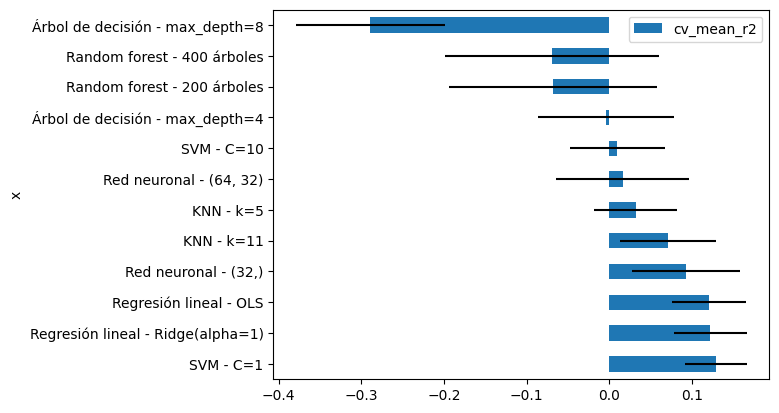

In [29]:
comparacion.plot(
    kind='barh',
    x='x',                # Categories on the Y-axis
    y='cv_mean_r2',        # Values on the X-axis
    xerr='cv_std_r2'       # Error bars on the X-axis (instead of yerr)
)

In [25]:
comparacion.plot?

Signature:      comparacion.plot(*args, **kwargs)
Type:           PlotAccessor
String form:    <pandas.plotting.PlotAccessor object at 0x137916520>
File:           ~/Development/UNAB/Teaching/R/my-r-project/Ejemplos/.venv_nb/lib/python3.14/site-packages/pandas/plotting/__init__.py
Docstring:     
Make plots of Series or DataFrame.

Uses the backend specified by the
option ``plotting.backend``. By default, matplotlib is used.

Parameters
----------
data : Series or DataFrame
    The object for which the method is called.

Attributes
----------
x : label or position, default None
    Only used if data is a DataFrame.
y : label, position or list of label, positions, default None
    Allows plotting of one column versus another. Only used if data is a
    DataFrame.
kind : str
    The kind of plot to produce:

    - 'line' : line plot (default)
    - 'bar' : vertical bar plot
    - 'barh' : horizontal bar plot
    - 'hist' : histogram
    - 'box' : boxplot
    - 'kde' : Kernel Density Esti

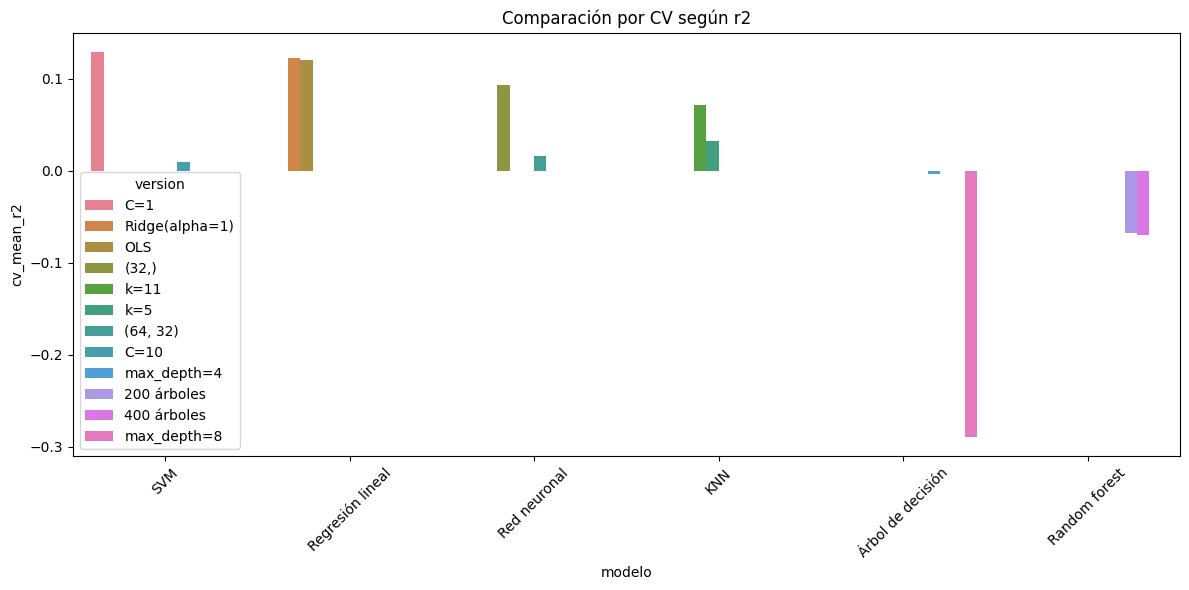

In [19]:
plt.figure(figsize=(12, 6))
sns.barplot(data=comparacion, x="modelo", y=f"cv_mean_{metrica_principal}", hue="version")
plt.title(f"Comparación por CV según {metrica_principal}")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
